# Tarea 3 2026 — Machine Learning

### Estudiante: Diego Álamos Valdivieso
### Carrera: Ingeniería Civil Matemática
### Asignatura: Data Analysis & Machine Learning
### Profesor: Juan Carlos Caro Seguel

# Pregunta 1

### Cargue la base de datos y realice los ajustes necesarios para su uso (missing values, recodificar variables, etcétera). Identifique los tipos de datos que se encuentran en la base, realice estadísticas descriptivas sobre las variables importantes (Hint: Revisar la distribuciones, datos faltantes, outliers, etc.) y limpie las variables cuando sea necesario. 

## Solución:

Primero que nada importamos las librerías necesarias para realizar un análisis de los datos, y seguidamente inspeccionamos nuestro panel de datos con las funciones `.head()` y `.shape` (esta último para conocer sus dimensiones).

In [95]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import sklearn
import scipy 
import statsmodels.api as sm
import statsmodels.formula.api as smf

import warnings
warnings.filterwarnings("ignore")

%matplotlib inline
sns.set_style("whitegrid")
sns.set_palette("muted")

In [96]:
df = pd.read_csv('junaeb2n.csv')
print(f'Dimensiones: {df.shape[0]} observaciones, {df.shape[1]} variables')
df.head(10)

Dimensiones: 41854 observaciones, 24 variables


,sexo,edad,imce,vive_padre,vive_madre,sk1,sk2,sk3,sk4,sk5,...,sk10,sk11,sk12,sk13,act_fisica,area,educm,educp,madre_work,narrative
0,1,85,0.75,1,1,1,1,1,2,1,...,2,2,3,2,NaN,0,11.0,11,-1,Las habilidades socioemocionales estan bien es...
1,0,76,0.71,0,1,1,1,1,1,1,...,1,1,1,1,5.0,0,8.0,8,1,"Exhibe un perfil socioemocional muy solido, si..."
2,1,68,0.27,0,1,2,2,3,2,1,...,3,2,1,3,NaN,1,13.0,13,1,"Su perfil socioemocional aun esta madurando, s..."
3,1,84,2.05,1,1,1,1,1,1,1,...,1,1,1,1,2.0,1,16.0,12,-1,"Alcanza un nivel socioemocional muy alto, de m..."
4,0,86,1.05,1,1,1,1,1,1,1,...,1,1,1,1,1.0,1,17.0,15,0,"Exhibe un perfil socioemocional muy solido, de..."
5,0,74,1.39,1,1,1,2,1,1,1,...,1,1,1,1,4.0,0,8.0,8,-1,Evidencia un desarrollo socioemocional excelen...
6,1,91,2.75,1,1,1,1,1,2,2,...,3,3,2,2,2.0,1,20.0,19,1,"Su perfil socioemocional es favorable, con lo ..."
7,1,92,1.53,1,1,1,3,1,1,3,...,4,3,2,4,1.0,1,13.0,11,0,Las habilidades socioemocionales se encuentran...
8,1,69,1.96,1,1,1,2,3,2,1,...,4,2,2,3,2.0,0,10.0,9,1,"Su nivel socioemocional es moderado, siendo la..."
9,1,84,1.76,1,1,1,1,1,1,1,...,1,1,1,1,3.0,1,17.0,17,1,"Su desarrollo socioemocional es sobresaliente,..."


Analizamos la información contenida en el set de datos en lo que respecta a los tipos de datos:

In [97]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41854 entries, 0 to 41853
Data columns (total 24 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   sexo        41854 non-null  int64  
 1   edad        41854 non-null  int64  
 2   imce        41854 non-null  float64
 3   vive_padre  41854 non-null  int64  
 4   vive_madre  41854 non-null  int64  
 5   sk1         41854 non-null  int64  
 6   sk2         41854 non-null  int64  
 7   sk3         41854 non-null  int64  
 8   sk4         41854 non-null  int64  
 9   sk5         41854 non-null  int64  
 10  sk6         41854 non-null  int64  
 11  sk7         41854 non-null  int64  
 12  sk8         41854 non-null  int64  
 13  sk9         41854 non-null  int64  
 14  sk10        41854 non-null  int64  
 15  sk11        41854 non-null  int64  
 16  sk12        41854 non-null  int64  
 17  sk13        41854 non-null  int64  
 18  act_fisica  40419 non-null  float64
 19  area        41854 non-nul

Notamos que la gran mayoría de las variables tienen la totalidad de las observaciones con datos no nulos. Veamos los datos faltantes relativos a sus variables:

In [98]:
missing = df.isna().sum()
missing = missing[missing > 0]
print('Variables con datos faltantes:')
print(missing)
print()
print('Porcentaje sobre el total:')
print((missing / len(df) * 100).round(2))

Variables con datos faltantes:
act_fisica    1435
educm          551
dtype: int64

Porcentaje sobre el total:
act_fisica    3.43
educm         1.32
dtype: float64


Ahora procedemos a determinar las estadísticas descriptivas generales:

In [99]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
sexo,41854.0,0.552325,0.497261,0.00,0.0,1.00,1.00,1.00
edad,41854.0,83.066039,3.987135,62.00,81.0,82.00,84.00,107.00
imce,41854.0,1.014083,1.380418,-5.02,0.1,0.97,1.93,5.04
vive_padre,41854.0,0.720051,0.449830,0.00,0.0,1.00,1.00,2.00
vive_madre,41854.0,0.965141,0.192328,0.00,1.0,1.00,1.00,2.00
sk1,41854.0,1.117958,0.401019,1.00,1.0,1.00,1.00,5.00
sk2,41854.0,1.397310,0.661753,1.00,1.0,1.00,2.00,5.00
sk3,41854.0,1.270129,0.594456,1.00,1.0,1.00,1.00,5.00
sk4,41854.0,1.263129,0.588868,1.00,1.0,1.00,1.00,5.00
sk5,41854.0,1.275935,0.575344,1.00,1.0,1.00,1.00,5.00


In [100]:
# Agrupamos las variables por su tipo real
vars_binarias = ['sexo', 'area']
vars_nominales = ['vive_padre', 'vive_madre', 'madre_work']

# Generamos automáticamente la lista para sk1 hasta sk13
vars_ordinales = [f'sk{i}' for i in range(1, 14)]

# Unimos todas para el análisis
todas_cat_vars = vars_binarias + vars_nominales + vars_ordinales

print("--- Distribución de Variables Categóricas y Binarias ---")
for c in todas_cat_vars:
    distribucion = (df[c].value_counts(normalize=True, dropna=False) * 100).round(1)
    
    print(f"\nVariable: {c}")
    for categoria, porcentaje in distribucion.items():
        print(f"  Categoría {categoria}: {porcentaje}%")

--- Distribución de Variables Categóricas y Binarias ---

Variable: sexo
  Categoría 1: 55.2%
  Categoría 0: 44.8%

Variable: area
  Categoría 1: 91.2%
  Categoría 0: 8.8%

Variable: vive_padre
  Categoría 1: 71.9%
  Categoría 0: 28.0%
  Categoría 2: 0.0%

Variable: vive_madre
  Categoría 1: 96.2%
  Categoría 0: 3.7%
  Categoría 2: 0.2%

Variable: madre_work
  Categoría 1: 49.0%
  Categoría -1: 40.7%
  Categoría 0: 10.3%

Variable: sk1
  Categoría 1: 90.5%
  Categoría 2: 7.6%
  Categoría 3: 1.6%
  Categoría 4: 0.2%
  Categoría 5: 0.1%

Variable: sk2
  Categoría 1: 68.7%
  Categoría 2: 24.1%
  Categoría 3: 6.3%
  Categoría 4: 0.6%
  Categoría 5: 0.3%

Variable: sk3
  Categoría 1: 79.4%
  Categoría 2: 15.4%
  Categoría 3: 4.3%
  Categoría 4: 0.6%
  Categoría 5: 0.3%

Variable: sk4
  Categoría 1: 79.9%
  Categoría 2: 15.2%
  Categoría 3: 4.1%
  Categoría 4: 0.6%
  Categoría 5: 0.3%

Variable: sk5
  Categoría 1: 78.0%
  Categoría 2: 17.3%
  Categoría 3: 4.1%
  Categoría 4: 0.5%
  Categoría

De lo anterior, podemos notar que `imce` ya viene truncado en [-5.02, 5.04], lo cual es un rango típico de un puntaje-z de IMC para edad. Ahora bien, `vive_padre` y `vive_madre` tienen una categoria 2 ("más de un padre/madre") muy minoritaria, lo cual las hace poco útiles a nivel ordinal independiente.

Pasamos a determinar los outliers de las variables numéricas más importantes, así como sus distribuciones:

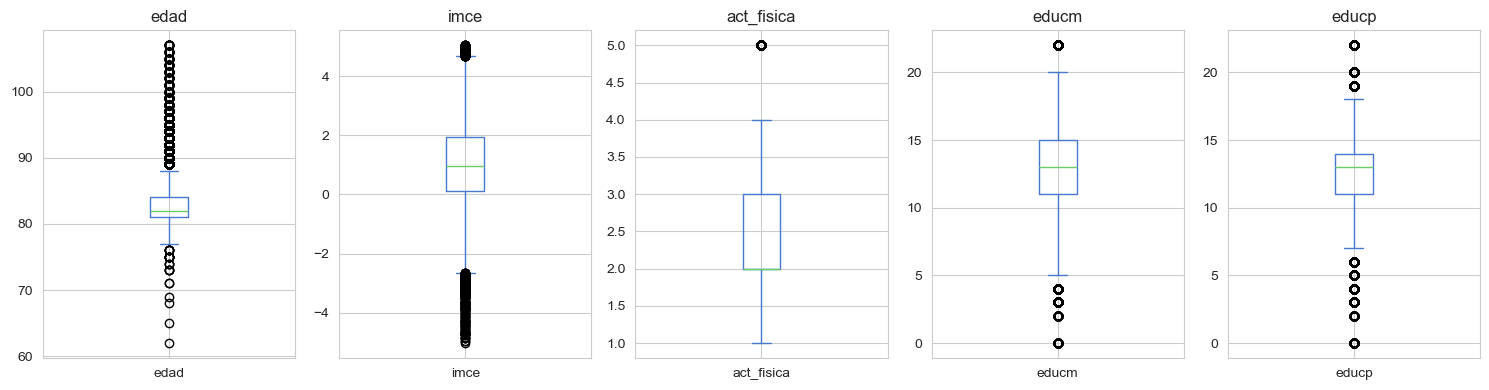

--- Detección de Outliers con el Método IQR ---

Variable: edad
  Límites IQR: [76.50, 88.50]
  Total Outliers: 4056 observaciones (9.69%)

Variable: imce
  Límites IQR: [-2.64, 4.67]
  Total Outliers: 426 observaciones (1.02%)

Variable: act_fisica
  Límites IQR: [0.50, 4.50]
  Total Outliers: 3263 observaciones (7.80%)

Variable: educm
  Límites IQR: [5.00, 21.00]
  Total Outliers: 1321 observaciones (3.16%)

Variable: educp
  Límites IQR: [6.50, 18.50]
  Total Outliers: 3878 observaciones (9.27%)


In [101]:
num_vars = ['edad', 'imce', 'act_fisica', 'educm', 'educp']

fig, axes = plt.subplots(1, len(num_vars), figsize=(15, 4))
for i, col in enumerate(num_vars):
    df[col].dropna().plot(kind='box', ax=axes[i], title=col)
plt.tight_layout()
plt.show()

print("--- Detección de Outliers con el Método IQR ---")
for col in num_vars:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < limite_inferior) | (df[col] > limite_superior)]
    porcentaje = (len(outliers) / len(df)) * 100
    
    print(f"\nVariable: {col}")
    print(f"  Límites IQR: [{limite_inferior:.2f}, {limite_superior:.2f}]")
    print(f"  Total Outliers: {len(outliers)} observaciones ({porcentaje:.2f}%)")

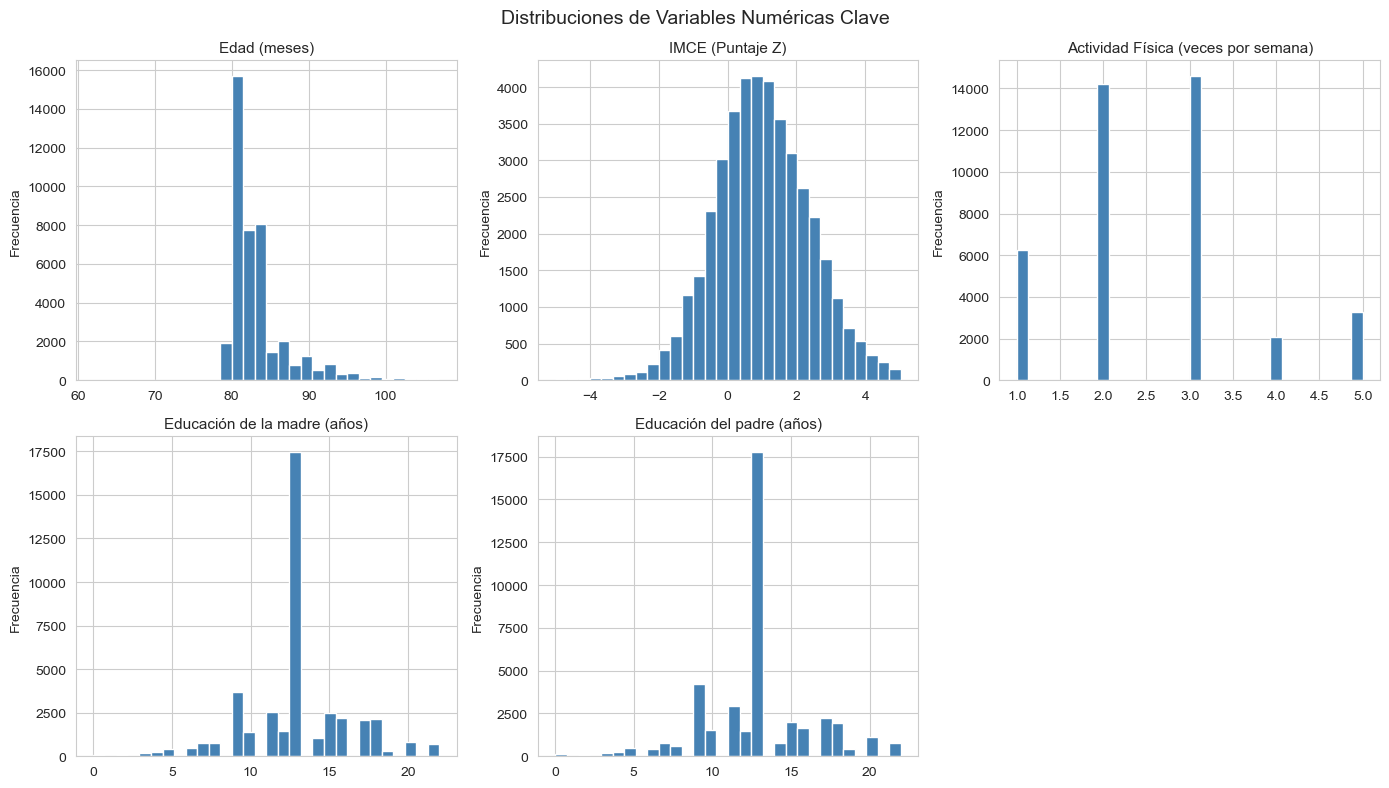

In [102]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle('Distribuciones de Variables Numéricas Clave', fontsize=14)

plot_vars = [
    ('edad', 'Edad (meses)'),
    ('imce', 'IMCE (Puntaje Z)'),
    ('act_fisica', 'Actividad Física (veces por semana)'),
    ('educm', 'Educación de la madre (años)'),
    ('educp', 'Educación del padre (años)')
]

axes_flat = axes.flatten()

for i, (var, label) in enumerate(plot_vars):
    axes_flat[i].hist(df[var].dropna(), bins=30, edgecolor='white', color='steelblue')
    axes_flat[i].set_title(label, fontsize=11)
    axes_flat[i].set_xlabel('')
    axes_flat[i].set_ylabel('Frecuencia')

axes_flat[5].set_visible(False)

plt.tight_layout()
plt.show()

**Limpieza final** 

A partir de todo el análisis efectuado anteriormente, se ha tomado la decisión de llevar a cabo los siguientes cambios:

- **Tipificación**: `sexo`, `area`, `vive_padre` y `vive_madre` son binarias, pero se mantienen como `int64` (no se castean a `category`). Conceptualmente son categóricas, pero los modelos de las Preguntas 4 y 5 (Random Forest, SVM, Stacking de Scikit-Learn) requieren entradas estrictamente numéricas, y `category` puede generar errores (en particular con SVM). Quedan documentadas como binarias, pero en formato numérico nativo.
- **`vive_padre` / `vive_madre`**: la categoría 2 ("más de un padre/madre") es marginal (0.04% y 0.17% de los casos respectivamente), por lo que se colapsa hacia 1, quedando ambas como variables binarias de convivencia (0/1).
- **`madre_work`**: se mantiene la versión numérica (-1/0/1) para los modelos y se agrega una versión etiquetada (`madre_work_cat`) solo para fines descriptivos. La exclusión de la categoría minoritaria ("desempleada") que pide explícitamente la Pregunta 4 se realizará en esa pregunta, y no en esta limpieza general, ya que las Preguntas 2, 3, 6 y 7 requieren la muestra completa.
- **Datos faltantes**: `act_fisica` (3.43%) y `educm` (1.32%) se imputan con la mediana.
- **Outliers de `imce`**: ya están acotados en torno a [-5, 5] (estándar en puntajes-z de IMC para edad), por lo que no se eliminan observaciones adicionales.
- **`edad`**: presenta cola derecha (hasta 107 meses) pero es consistente con estudiantes repitentes o de ingreso tardío; se mantiene sin recortar, ya que no hay evidencia de error de digitación (todos los valores son enteros plausibles en meses).

Creamos el código para hacer estos cambios:

In [103]:
df['vive_padre'] = df['vive_padre'].replace(2, 1)
df['vive_madre'] = df['vive_madre'].replace(2, 1)

mapa_madre_work = {-1: 'labor_domestica', 0: 'desempleada', 1: 'empleada'}
df['madre_work_cat'] = df['madre_work'].map(mapa_madre_work).astype('category')

for col in ['act_fisica', 'educm']:
    df[col] = df[col].fillna(df[col].median())

vars_binarias = ['sexo', 'area', 'vive_padre', 'vive_madre']
df[vars_binarias] = df[vars_binarias].astype(int)

print(f"\nValores faltantes totales en el dataset: {df.isna().sum().sum()}")
print(f"Dimensiones finales: {df.shape}")
df.dtypes


Valores faltantes totales en el dataset: 0
Dimensiones finales: (41854, 25)


sexo                 int64
edad                 int64
imce               float64
vive_padre           int64
vive_madre           int64
sk1                  int64
sk2                  int64
sk3                  int64
sk4                  int64
sk5                  int64
sk6                  int64
sk7                  int64
sk8                  int64
sk9                  int64
sk10                 int64
sk11                 int64
sk12                 int64
sk13                 int64
act_fisica         float64
area                 int64
educm              float64
educp                int64
madre_work           int64
narrative           object
madre_work_cat    category
dtype: object

Finalmente, hacemos un casteo final de las variables `educm` y `act_fisica` a `int64` y creamos el dataset final `df_clean`. Ambas variables son de naturaleza discreta (años de escolaridad y categoría ordinal de frecuencia) y, una vez imputados los valores faltantes con la mediana, todos sus valores son enteros (la mediana cae exactamente en 13 para `educm` y en 2 para `act_fisica`), por lo que covertirlas a `int64` no trae problemas.

In [104]:
df['educm'] = df['educm'].astype('int64')
df['act_fisica'] = df['act_fisica'].astype('int64')

df_clean = df.copy()

print(f"\nValores faltantes: {df_clean.isna().sum().sum()}")
print(f"Dimensiones finales: {df_clean.shape}")
df_clean.dtypes


Valores faltantes: 0
Dimensiones finales: (41854, 25)


sexo                 int64
edad                 int64
imce               float64
vive_padre           int64
vive_madre           int64
sk1                  int64
sk2                  int64
sk3                  int64
sk4                  int64
sk5                  int64
sk6                  int64
sk7                  int64
sk8                  int64
sk9                  int64
sk10                 int64
sk11                 int64
sk12                 int64
sk13                 int64
act_fisica           int64
area                 int64
educm                int64
educp                int64
madre_work           int64
narrative           object
madre_work_cat    category
dtype: object

Guardamos nuestro dataset limpio para trabajar en las siguientes preguntas:

In [105]:
df_clean.to_csv('junaeb2n_clean.csv', index=False)

# Pregunta 2

### A partir de las variables sk1-sk13 realice un EFA. En particular determine el número óptimo de factores y reporte las variables que se asocian a cada factor (usando los factor loadings). También discuta si existen variables que no son informativas. (Hint: para realizar un EFA, todas las variables deben estar representatadas en el mismo sentido lógico. Si una caraterística es negativa debe ser invertida en la escala, de tal forma que todas las variables representen aspectos positivos).

## Solución:

Primero que nada, cargamos el dataset limpio y definimos las variables *sk*:

In [106]:
from factor_analyzer import FactorAnalyzer, calculate_bartlett_sphericity, calculate_kmo

df = pd.read_csv('junaeb2n_clean.csv')
sk_cols = [f'sk{i}' for i in range(1, 14)]
X = df[sk_cols]

Adecuamos los datos para poder realizar el EFA y los indicadores estadísticos de Bartlett y KMO:

In [107]:
chi2, p_value = calculate_bartlett_sphericity(X)
kmo_per_var, kmo_total = calculate_kmo(X)

print(f'Test de esfericidad de Bartlett: chi2 = {chi2:.1f}, p-valor = {p_value:.4f}')
print(f'KMO global: {kmo_total:.3f}')
print()
print('KMO por variable:')
for c, v in zip(sk_cols, kmo_per_var):
    print(f'  {c}: {v:.3f}')

Test de esfericidad de Bartlett: chi2 = 122116.7, p-valor = 0.0000
KMO global: 0.873

KMO por variable:
  sk1: 0.870
  sk2: 0.881
  sk3: 0.861
  sk4: 0.859
  sk5: 0.845
  sk6: 0.875
  sk7: 0.788
  sk8: 0.873
  sk9: 0.898
  sk10: 0.879
  sk11: 0.876
  sk12: 0.895
  sk13: 0.894


Notamos que el test de Bartlett rechaza la hipótesis de que la matriz de correlaciones es una matriz identidad (p < 0.001), y el KMO global es 0.87. Ambos resultados confirman que las variables `sk1`-`sk13` tienen suficiente correlación compartida para justificar un EFA. El único KMO individual notoriamente más bajo es el de `sk7` (0.79), una primera señal de que esta variable aporta menos información compartida con el resto.

Ahora procedemos a determinar el número óptimo de factores con el Criterio de Kaiser:

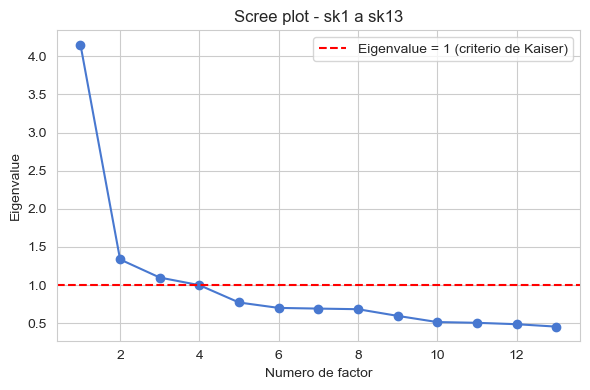

Eigenvalues: [4.154 1.337 1.099 0.999 0.772 0.701 0.692 0.684 0.597 0.516 0.506 0.487
 0.456]
N factores con eigenvalue > 1: 3


In [108]:
fa_full = FactorAnalyzer(rotation=None, n_factors=len(sk_cols), method='ml')
fa_full.fit(X)
eigenvalues, _ = fa_full.get_eigenvalues()

plt.figure(figsize=(6, 4))
plt.plot(range(1, len(eigenvalues) + 1), eigenvalues, 'o-')
plt.axhline(1, color='red', linestyle='--', label='Eigenvalue = 1 (criterio de Kaiser)')
plt.xlabel('Numero de factor')
plt.ylabel('Eigenvalue')
plt.title('Scree plot - sk1 a sk13')
plt.legend()
plt.tight_layout()
plt.show()

print('Eigenvalues:', np.round(eigenvalues, 3))
print('N factores con eigenvalue > 1:', (eigenvalues > 1).sum())

A modo de complemento, realizamos un análsis paralelo (Horn) como validación adicional del número de factores:

In [109]:
np.random.seed(42)
n_iter = 50
n, p = X.shape
rand_eigs = np.zeros((n_iter, p))
fa_rand = FactorAnalyzer(rotation=None, n_factors=p, method='ml')

for i in range(n_iter):
    X_rand = np.random.normal(size=(n, p))
    fa_rand.fit(X_rand)
    ev_r, _ = fa_rand.get_eigenvalues()
    rand_eigs[i, :] = ev_r

mean_rand = rand_eigs.mean(axis=0)

comparison = pd.DataFrame({
    'Eigenvalue_real': eigenvalues,
    'Eigenvalue_aleatorio': mean_rand,
    'Retener': eigenvalues > mean_rand
}, index=[f'Factor {i+1}' for i in range(p)])
comparison.round(3)

,Eigenvalue_real,Eigenvalue_aleatorio,Retener
Factor 1,4.154,1.029,True
Factor 2,1.337,1.022,True
Factor 3,1.099,1.017,True
Factor 4,0.999,1.012,False
Factor 5,0.772,1.008,False
Factor 6,0.701,1.004,False
Factor 7,0.692,1.000,False
Factor 8,0.684,0.996,False
Factor 9,0.597,0.992,False
Factor 10,0.516,0.987,False


El **criterio de Kaiser** (eigenvalue > 1) y el ánalisis paralelo de **Horn** coinciden en **retener 3 factores**: los tres primeros eigenvalues reales (4.15, 1.34, 1.10) superan tanto el umbral de 1 como el eigenvalue esperado bajo datos aleatorios del mismo tamaño, mientras que el cuarto factor (eigenvalue = 0.999) queda por debajo de ambos referentes. Se opta por una **rotación oblicua (promax)**, ya que conceptualmente no hay razón para asumir que las dimensiones socioemocionales sean independientes entre sí.

In [110]:
fa = FactorAnalyzer(n_factors=3, rotation='promax', method='ml')
fa.fit(X)

loadings = pd.DataFrame(
    fa.loadings_, index=sk_cols, columns=['Factor_1', 'Factor_2', 'Factor_3']
)
comunalidad = pd.Series(fa.get_communalities(), index=sk_cols, name='Comunalidad_h2')

tabla_efa = pd.concat([loadings, comunalidad], axis=1).round(3)
tabla_efa

,Factor_1,Factor_2,Factor_3,Comunalidad_h2
sk1,0.037,0.603,-0.049,0.367
sk2,-0.026,0.490,0.218,0.289
sk3,0.001,0.697,-0.051,0.489
sk4,-0.019,0.767,-0.025,0.589
sk5,-0.188,-0.016,0.907,0.858
sk6,0.011,0.059,0.502,0.255
sk7,0.050,0.033,0.100,0.014
sk8,0.136,-0.106,0.531,0.312
sk9,0.517,0.084,0.037,0.276
sk10,0.635,-0.040,-0.044,0.407


Determinamos la varianza explicada y la correlación entre factores:

In [111]:
var, prop_var, cum_var = fa.get_factor_variance()
print('Proporción de varianza explicada por factor:', np.round(prop_var, 3))
print('Varianza acumulada:', np.round(cum_var, 3))
print()
print('Correlación entre factores (rotación oblicua):')
print(pd.DataFrame(fa.phi_, index=['Factor_1', 'Factor_2', 'Factor_3'],
                    columns=['Factor_1', 'Factor_2', 'Factor_3']).round(2))

Proporción de varianza explicada por factor: [0.143 0.131 0.11 ]
Varianza acumulada: [0.143 0.274 0.383]

Correlación entre factores (rotación oblicua):
          Factor_1  Factor_2  Factor_3
Factor_1      1.00      0.59      0.65
Factor_2      0.59      1.00      0.63
Factor_3      0.65      0.63      1.00


### Interpretación de los factores

Usando un umbral de |loading| >= 0.40 como criterio de asociación relevante (convención habitual en EFA), la estructura encontrada es:

- **Factor 1 - Curiosidad e interés exploratorio**: `sk9` (preguntas a adultos), `sk10` (interés por libros), `sk11` (interés por el entorno), `sk12` (armar/desarmar cosas) y `sk13` (expresiones artísticas). Agrupa comportamientos de exploración cognitiva y curiosidad.
- **Factor 2 - Expresión afectivo-emocional**: `sk1` (afecto a padres), `sk2` (afecto a pares, carga moderada), `sk3` (expresa sentimientos) y `sk4` (usa gestos para expresar sentimientos). Agrupa la capacidad de mostrar y comunicar emociones.
- **Factor 3 - Juego social**: `sk5` (juega con otros), `sk6` (comparte sus cosas) y `sk8` (participa en juegos grupales). Agrupa comportamientos de interacción social ludica.

**Variable no informativa:** `sk7` ("es agresivo") no supera el umbral de 0.40 en ningún factor (cargas de 0.05, 0.03 y 0.10) y su comunalidad es de solo 0.014 (es decir, el modelo de 3 factores explica apenas el 1.4% de su varianza, muy por debajo del resto de variables, cuyas comunalidades van de 0.25 a 0.86). Esto confirma que `sk7` no se asocia de forma relevante con ninguna de las tres dimensiones latentes encontradas y por lo tanto se excluye del CFA en la Pregunta 3.

Por último, las correlaciones entre los tres factores (oblicuas) son todas moderadas-altas, lo que confirma que las dimensiones socioemocionales, si bien conceptualmente distintas, están relacionadas entre sí justificando el uso de rotación oblicua en vez de ortogonal (varimax).

# Pregunta 3

### Con los resultados obtenidos en la Pregunta 2, proponga un CFA donde cada variable sólo se asocia con un factor. Entregue un nombre a cada factor que representa el concepto común entre las variables incluidas. Reporte la importancia de cada medida (variable) a cada factor e indique la correlación entre factores (loadings). Guarde sus predicciones.

## Solución:

A partir de la estructura encontrada en el EFA, proponemos un CFA donde **cada variable se asocia exclusivamente a un factor** (a diferencia del EFA, que permite cargas cruzadas). Se excluye `sk7` por su comunalidad casi nula. Los tres factores se dejan correlacionados entre sí (no se fuerza ortogonalidad), siguiendo la misma lógica de la rotación oblicua usada en el EFA.

**Especificación del modelo:**

- `Curiosidad =~ sk9 + sk10 + sk11 + sk12 + sk13`
- `Afecto =~ sk1 + sk2 + sk3 + sk4`
- `JuegoSocial =~ sk5 + sk6 + sk8`

In [112]:
import pandas as pd
import numpy as np
import semopy
from semopy import calc_stats

df = pd.read_csv('junaeb2n_clean.csv')

model_desc = '''
Curiosidad =~ sk9 + sk10 + sk11 + sk12 + sk13
Afecto =~ sk1 + sk2 + sk3 + sk4
JuegoSocial =~ sk5 + sk6 + sk8
'''

cfa_model = semopy.Model(model_desc)
cfa_model.fit(df)

SolverResult(fun=0.14689387903452733, success=True, n_it=42, x=array([1.30617692, 1.21525563, 1.07723775, 1.26466836, 1.79279259,
       1.59626955, 1.75094249, 1.02713692, 1.1386392 , 0.05790578,
       0.06104905, 0.17191267, 0.17286491, 0.06588178, 0.10277236,
       0.10295093, 0.62646598, 0.21435727, 0.45861015, 0.73021906,
       0.25155377, 0.20586137, 0.16928298, 0.1581823 , 0.37549023,
       0.49196317, 0.29352518]), message='Optimization terminated successfully', name_method='SLSQP', name_obj='MLW')

Determinamos las cargas factoriales (loadings) estandarizadas:

In [113]:
inspect = cfa_model.inspect(std_est=True)

loadings_cfa = inspect[inspect['op'] == '~'][['lval', 'rval', 'Est. Std', 'p-value']]
loadings_cfa.columns = ['Variable', 'Factor', 'Loading_estandarizado', 'p-value']
loadings_cfa = loadings_cfa.sort_values(['Factor', 'Loading_estandarizado'], ascending=[True, False])
loadings_cfa.round(3)

,Variable,Factor,Loading_estandarizado,p-value
8,sk4,Afecto,0.715,0.0
6,sk2,Afecto,0.652,0.0
7,sk3,Afecto,0.646,0.0
5,sk1,Afecto,0.600,-
2,sk11,Curiosidad,0.736,0.0
0,sk9,Curiosidad,0.608,-
1,sk10,Curiosidad,0.565,0.0
3,sk12,Curiosidad,0.551,0.0
4,sk13,Curiosidad,0.523,0.0
9,sk5,JuegoSocial,0.723,-


Todas las cargas son significativas (p < 0.001) y superan 0.5, lo que indica una asociación fuerte entre cada ítem y su factor:

- **Curiosidad**: el indicador más fuerte es `sk11` (interés por el entorno, 0.74), seguido por `sk9` (0.61); `sk13` (expresión artística, 0.52) es el más débil del grupo.
- **Afecto**: `sk4` (usa gestos para mostrar sentimientos, 0.72) es el indicador más fuerte; `sk1` (afecto a padres, 0.60) el más débil.
- **JuegoSocial**: `sk5` (jugar con otros, 0.72) domina claramente sobre `sk6` y `sk8` (~0.56-0.57).

Estos resultados son coherentes con los loadings (rotados) obtenidos en el EFA, confirmando la estabilidad de la estructura encontrada.

Veamos los Índices de Ajuste del Modelo:

In [114]:
stats = calc_stats(cfa_model)
stats[['DoF', 'chi2', 'chi2 p-value', 'CFI', 'TLI', 'GFI', 'RMSEA', 'AIC', 'BIC']].T

,Value
DoF,51.000000
chi2,6148.096413
chi2 p-value,0.000000
CFI,0.949192
TLI,0.934249
GFI,0.948795
RMSEA,0.053446
AIC,53.706212
BIC,287.038664


Usando los criterios convencionales (CFI/TLI > 0.90 aceptable, > 0.95 bueno; RMSEA < 0.05 ajuste cercano, < 0.08 razonable), el modelo obtiene **CFI = 0.95**, **TLI = 0.93** y **RMSEA = 0.053**, lo que indica un ajuste aceptable a bueno.

Ahora veamos la Correlación entre Factores:

In [115]:
cov_factores = inspect[(inspect['op'] == '~~') &
                        (inspect['lval'].isin(['Curiosidad', 'Afecto', 'JuegoSocial'])) &
                        (inspect['rval'].isin(['Curiosidad', 'Afecto', 'JuegoSocial']))]
cov_factores[['lval', 'rval', 'Est. Std']].round(3)

,lval,rval,Est. Std
12,Afecto,Afecto,1.000
13,Afecto,Curiosidad,0.612
14,Curiosidad,Curiosidad,1.000
15,JuegoSocial,JuegoSocial,1.000
16,JuegoSocial,Afecto,0.658
17,JuegoSocial,Curiosidad,0.596


Notamos que las correlaciones entre los tres factores latentes son moderadas-altas (Afecto-Curiosidad = 0.61, Afecto-JuegoSocial = 0.66, Curiosidad-JuegoSocial = 0.60), en línea con lo encontrado en el EFA (0.58-0.65). Esto sugiere que, si bien las tres dimensiones son conceptualmente distintas, comparten una base común de desarrollo socioemocional en los niños.

Finalmente, hacemos nuestra predicciones:

In [116]:
factor_scores = cfa_model.predict_factors(df)
factor_scores = factor_scores.rename(columns={
    'Curiosidad': 'factor_curiosidad',
    'Afecto': 'factor_afecto',
    'JuegoSocial': 'factor_juego_social'
})

df_factores = pd.concat([df.reset_index(drop=True), factor_scores.reset_index(drop=True)], axis=1)
print(df_factores[['factor_curiosidad', 'factor_afecto', 'factor_juego_social']].describe())

df_factores.to_csv('junaeb2n_factores.csv', index=False)

       factor_curiosidad  factor_afecto  factor_juego_social
count       4.185400e+04   4.185400e+04         4.185400e+04
mean       -1.052555e-16  -6.790679e-19        -5.755101e-17
std         3.667807e-01   2.137515e-01         3.556225e-01
min        -3.527977e-01  -1.599777e-01        -3.081028e-01
25%        -2.749094e-01  -1.445714e-01        -2.693130e-01
50%        -1.123040e-01  -8.441530e-02        -1.255303e-01
75%         1.789164e-01   6.557954e-02         1.514009e-01
max         2.767411e+00   2.019809e+00         3.000618e+00


**Nombres finales de los factores**:

1. **`factor_curiosidad`** - Curiosidad y exploracion cognitiva (sk9, sk10, sk11, sk12, sk13).
2. **`factor_afecto`** - Expresion afectivo-emocional (sk1, sk2, sk3, sk4).
3. **`factor_juego_social`** - Juego e interaccion social con pares (sk5, sk6, sk8).

Las predicciones (factor scores) quedan guardadas en `junaeb2n_factores.csv`, base que se usara como input de features en la Pregunta 4 (Random Forest).

# Pregunta 4

### Usando los features del modelo de la Pregunta 3, entrene un modelo Random Forest para clasificar la muestra usando la variable madre_work como target. Para facilitar el problema, excluya las personas desempleadas (categoria minoritaria). Recuerde tanto la optimización de hiperparámetros como la validación de pliegues (k-fold).

## Solución:

**Features**: usamos los tres *factor scores* estimados en el CFA de la Pregunta 3 (`factor_curiosidad`, `factor_afecto`, `factor_juego_social`) como únicas variables predictoras (en vez de alimentar el modelo con las 12 variables `sk` originales (con ruido de medición propio), usaremos directamente las dimensiones latentes ya depuradas).

**Target**: `madre_work`. Siguiendo las instrucciones, excluimos a las madres desempleadas (`0`) y clasificamos entre **empleada** (`1`) y **labor domestica** (`-1`).

In [117]:
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score

df = pd.read_csv('junaeb2n_factores.csv')
sub = df[df['madre_work'] != 0].copy()

feature_cols = ['factor_curiosidad', 'factor_afecto', 'factor_juego_social']
X = sub[feature_cols]
y = (sub['madre_work'] == 1).astype(int)

print(f'N observaciones: {len(sub)}')
print('Balance de clases:')
print(y.value_counts(normalize=True).round(3))

N observaciones: 37545
Balance de clases:
madre_work
1    0.547
0    0.453
Name: proportion, dtype: float64


Tras excluir a las desempleadas, las clases quedan moderadamente balanceadas (54.6% empleada vs. 45.4% labor domestica), por lo que el accuracy y la matriz de confusión son métricas apropiadas (no se requieren correcciones por desbalance).

Procedemos a crear los conjuntos de datos de entrenamiento y de testeo, así como llevar a cabo el proceso de optimización de hiperparámetros con validación cruzada (5-fold):

In [118]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train: {X_train.shape[0]} obs | Test: {X_test.shape[0]} obs')

Train: 30036 obs | Test: 7509 obs


In [119]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 8],
    'min_samples_leaf': [1, 10]
}

rf = RandomForestClassifier(random_state=42, n_jobs=1)
grid_rf = GridSearchCV(rf, param_grid, cv=5, scoring='accuracy', n_jobs=1)

t0 = time.time()
grid_rf.fit(X_train, y_train)
tiempo_rf = time.time() - t0

print(f'Tiempo de busqueda de hiperparámetros: {tiempo_rf:.1f} s')
print('Mejores hiperparámetros:', grid_rf.best_params_)
print('Mejor accuracy promedio (5-fold CV):', round(grid_rf.best_score_, 4))

Tiempo de busqueda de hiperparámetros: 133.5 s
Mejores hiperparámetros: {'max_depth': 3, 'min_samples_leaf': 1, 'n_estimators': 100}
Mejor accuracy promedio (5-fold CV): 0.5519


Evaluamos en el set de prueba y creamos la matriz de confusión:

                 precision    recall  f1-score   support

labor_domestica      0.574     0.058     0.105      3405
       empleada      0.552     0.964     0.702      4104

       accuracy                          0.553      7509
      macro avg      0.563     0.511     0.404      7509
   weighted avg      0.562     0.553     0.432      7509



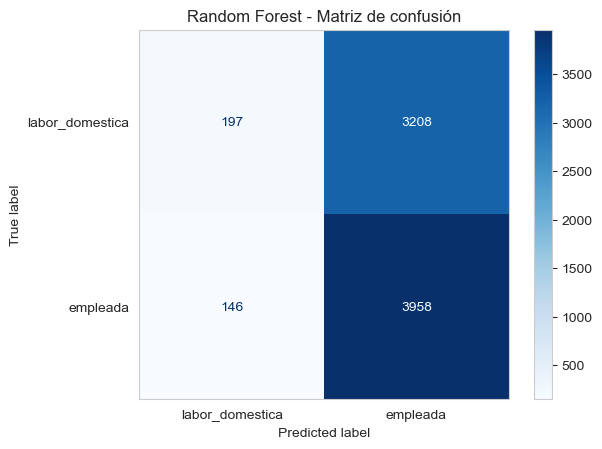

AUC: 0.5251
Accuracy modelo: 0.5533  |  Accuracy línea base (clase mayoritaria): 0.5465


In [120]:
best_rf = grid_rf.best_estimator_
y_pred_rf = best_rf.predict(X_test)
y_proba_rf = best_rf.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_rf, digits=3, target_names=['labor_domestica', 'empleada']))

cm_rf = confusion_matrix(y_test, y_pred_rf)
ConfusionMatrixDisplay(cm_rf, display_labels=['labor_domestica', 'empleada']).plot(cmap='Blues')
plt.grid(False)
plt.title('Random Forest - Matriz de confusión')
plt.show()

auc_rf = roc_auc_score(y_test, y_proba_rf)
baseline_acc = max(y_test.mean(), 1 - y_test.mean())
print(f'AUC: {auc_rf:.4f}')
print(f'Accuracy modelo: {(y_pred_rf == y_test).mean():.4f}  |  Accuracy línea base (clase mayoritaria): {baseline_acc:.4f}')

Analizamos la importancia de los features en este modelo:

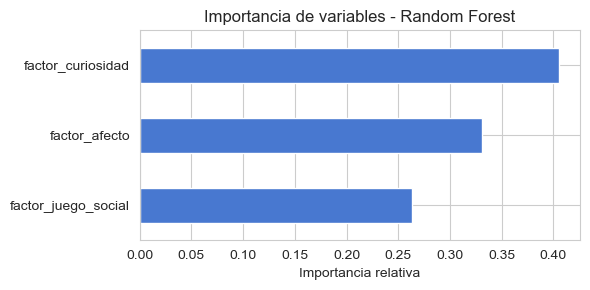

factor_juego_social    0.263
factor_afecto          0.331
factor_curiosidad      0.406
dtype: float64

In [121]:
importancias = pd.Series(best_rf.feature_importances_, index=feature_cols).sort_values()
importancias.plot(kind='barh', figsize=(6, 3), title='Importancia de variables - Random Forest')
plt.xlabel('Importancia relativa')
plt.tight_layout()
plt.show()
importancias.round(3)

De todo lo anterior podemos decir lo siguiente:

- La busqueda de hiperparámetros seleccionó un bosque relativamente poco profundo (`max_depth = 3`), lo cual ya es una señal de que el algoritmo no encuentra patrones complejos que valga la pena explotar con arboles mas grandes.

- El resultado central es que el modelo no logra superar de manera significativa a un modelo base de predicción (accuracy ≈ 0.55 vs. 0.55 de la línea base de predecir siempre la clase mayoritaria), y el AUC (≈0.53) está muy cerca de 0.5 (equivalente a azar). La matriz de confusión confirma que el modelo predice 'empleada' para la gran mayoria de los casos, acertando casi todos los verdaderos positivos pero fallando sistemáticamente en identificar a las madres en labor domestica (recall ≈ 0.06 en esa clase).

- Se podría decir que no hay razón teórica fuerte para esperar que el perfil socioemocional de un niño de 7 años sea un buen predictor de la situación laboral de su madre. Las tres variables latentes simplemente no contienen suficiente señal relevante para este target, más allá de posibles correlaciones indirectas.

# Pregunta 5

### Compare los resultados de la Pregunta 4 usando los modelos XGBoost, Support Vector Machine y Stacking. Discuta sus resultados respecto de la parte 5, tanto en la matriz de confusión, como la eficiencia (velocidad de cómputo).

## Solución:

Usamos exactamente el mismo set de features, target y partición train/test de la Pregunta 4, de modo que los resultados sean directamente comparables.

In [122]:
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score
from xgboost import XGBClassifier

df = pd.read_csv('junaeb2n_factores.csv')
sub = df[df['madre_work'] != 0].copy()
feature_cols = ['factor_curiosidad', 'factor_afecto', 'factor_juego_social']
X = sub[feature_cols]
y = (sub['madre_work'] == 1).astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

resultados = {}

**Random Forest:** reutilizamos los hiperparámetros ya optimizados en la Pregunta 4.

In [123]:
t0 = time.time()
rf_final = RandomForestClassifier(n_estimators=100, max_depth=3, min_samples_leaf=1,
                                   random_state=42, n_jobs=1)
rf_final.fit(X_train, y_train)
t_rf = time.time() - t0

y_pred = rf_final.predict(X_test)
y_proba = rf_final.predict_proba(X_test)[:, 1]
resultados['RandomForest'] = {
    'fit_time': t_rf, 'search_time': np.nan,
    'accuracy': (y_pred == y_test).mean(), 'auc': roc_auc_score(y_test, y_proba),
    'cm': confusion_matrix(y_test, y_pred)
}
print(f'RF -> tiempo ajuste final: {t_rf:.2f} s')

RF -> tiempo ajuste final: 1.18 s


**XGBoost:** hacemos la optimización de hiperparámetros (5-fold con Validación Cruzada) más el ajuste final.

In [124]:
param_grid_xgb = {'n_estimators': [100, 200], 'max_depth': [3, 5], 'learning_rate': [0.05, 0.1]}
xgb = XGBClassifier(random_state=42, n_jobs=1, eval_metric='logloss')
grid_xgb = GridSearchCV(xgb, param_grid_xgb, cv=5, scoring='accuracy', n_jobs=1)

t0 = time.time()
grid_xgb.fit(X_train, y_train)
t_search_xgb = time.time() - t0
print(f'XGBoost -> tiempo búsqueda HP: {t_search_xgb:.2f} s | mejores params: {grid_xgb.best_params_}')

t0 = time.time()
xgb_final = XGBClassifier(**grid_xgb.best_params_, random_state=42, n_jobs=1, eval_metric='logloss')
xgb_final.fit(X_train, y_train)
t_fit_xgb = time.time() - t0

y_pred = xgb_final.predict(X_test)
y_proba = xgb_final.predict_proba(X_test)[:, 1]
resultados['XGBoost'] = {
    'fit_time': t_fit_xgb, 'search_time': t_search_xgb,
    'accuracy': (y_pred == y_test).mean(), 'auc': roc_auc_score(y_test, y_proba),
    'cm': confusion_matrix(y_test, y_pred)
}
print(f'XGBoost -> tiempo ajuste final: {t_fit_xgb:.2f} s')

XGBoost -> tiempo búsqueda HP: 10.50 s | mejores params: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}
XGBoost -> tiempo ajuste final: 0.13 s


**SVM:** para lograr una buena eficiencia computacional, el tuning se hace sobre una submuestra estratificada de 5.000 observaciones, y sólo el modelo final (con los mejores hiperparámetros) se entrena sobre el set de entrenamiento completo.

In [125]:
X_sub, _, y_sub, _ = train_test_split(X_train, y_train, train_size=5000, random_state=42, stratify=y_train)
scaler_sub = StandardScaler().fit(X_sub)
X_sub_s = scaler_sub.transform(X_sub)

param_grid_svc = {'C': [0.1, 1, 10], 'gamma': ['scale', 'auto']}
svc_search = SVC(kernel='rbf', probability=False, random_state=42)
grid_svc = GridSearchCV(svc_search, param_grid_svc, cv=3, scoring='accuracy', n_jobs=1)

t0 = time.time()
grid_svc.fit(X_sub_s, y_sub)
t_search_svc = time.time() - t0
print(f'SVM -> tiempo búsqueda HP (submuestra 5.000): {t_search_svc:.2f} s | mejores params: {grid_svc.best_params_}')

scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_test_s = scaler.transform(X_test)

t0 = time.time()
svc_final = SVC(kernel='rbf', **grid_svc.best_params_, probability=False, random_state=42)
svc_final.fit(X_train_s, y_train)
t_fit_svc = time.time() - t0

y_pred = svc_final.predict(X_test_s)
y_score = svc_final.decision_function(X_test_s)
resultados['SVM'] = {
    'fit_time': t_fit_svc, 'search_time': t_search_svc,
    'accuracy': (y_pred == y_test).mean(), 'auc': roc_auc_score(y_test, y_score),
    'cm': confusion_matrix(y_test, y_pred)
}
print(f'SVM -> tiempo ajuste final (set completo): {t_fit_svc:.2f} s')

SVM -> tiempo búsqueda HP (submuestra 5.000): 29.24 s | mejores params: {'C': 0.1, 'gamma': 'auto'}
SVM -> tiempo ajuste final (set completo): 40.28 s


**Stacking:** acá combinamos RF, XGBoost y SVM con un meta-modelo de regresión logística.

In [126]:
rf_base = RandomForestClassifier(n_estimators=100, max_depth=3, min_samples_leaf=1, random_state=42, n_jobs=1)
xgb_base = XGBClassifier(**grid_xgb.best_params_, random_state=42, n_jobs=1, eval_metric='logloss')
svc_base = make_pipeline(StandardScaler(),
                          SVC(kernel='rbf', **grid_svc.best_params_, probability=False, random_state=42))

stack = StackingClassifier(
    estimators=[('rf', rf_base), ('xgb', xgb_base), ('svc', svc_base)],
    final_estimator=LogisticRegression(),
    cv=3, n_jobs=1, stack_method='auto'
)

t0 = time.time()
stack.fit(X_train, y_train)
t_fit_stack = time.time() - t0

y_pred = stack.predict(X_test)
y_proba = stack.predict_proba(X_test)[:, 1]
resultados['Stacking'] = {
    'fit_time': t_fit_stack, 'search_time': np.nan,
    'accuracy': (y_pred == y_test).mean(), 'auc': roc_auc_score(y_test, y_proba),
    'cm': confusion_matrix(y_test, y_pred)
}
print(f'Stacking -> tiempo ajuste total: {t_fit_stack:.2f} s')

Stacking -> tiempo ajuste total: 187.11 s


Construimos una tabla comparativa para contrastar a los modelos en cuanto a desempeño y eficiencia:

In [127]:
tabla = pd.DataFrame({
    modelo: {
        'Accuracy': r['accuracy'], 'AUC': r['auc'],
        'Tiempo busqueda HP (s)': r['search_time'],
        'Tiempo ajuste final (s)': r['fit_time']
    } for modelo, r in resultados.items()
}).T
tabla.round(3)

,Accuracy,AUC,Tiempo busqueda HP (s),Tiempo ajuste final (s)
RandomForest,0.553,0.525,NaN,1.177
XGBoost,0.552,0.525,10.503,0.129
SVM,0.552,0.533,29.239,40.280
Stacking,0.552,0.525,NaN,187.106


Construimos las matrices de confusión de los modelos:

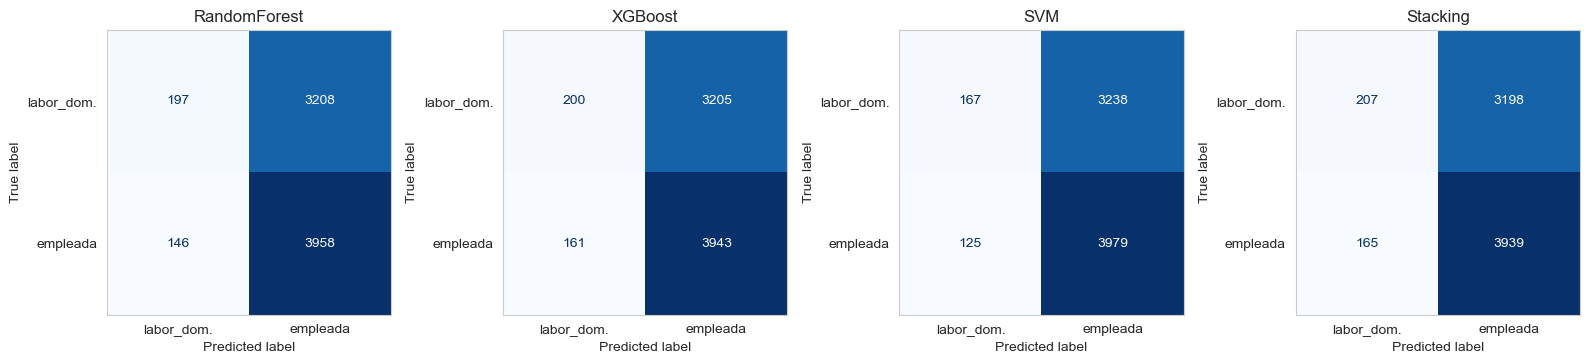

In [128]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, (modelo, r) in zip(axes, resultados.items()):
    ConfusionMatrixDisplay(r['cm'], display_labels=['labor_dom.', 'empleada']).plot(ax=ax, cmap='Blues', colorbar=False)
    ax.grid(False) 
    ax.set_title(modelo)
plt.tight_layout()
plt.show()

**Desempeño (matriz de confusión):** los cuatro modelos llegan prácticamente al mismo punto: Accuracy ≈ 0.55 y AUC ≈ 0.52-0.53, todos muy cerca de la regla trivial de predecir siempre 'empleada' (línea base ≈ 0.547). En las cuatro matrices de confusión se repite el mismo patrón: alto recall en la clase mayoritaría, recall muy bajo en 'labor_domestica', lo que confirma que el límite no está en el algoritmo sino en la falta de señal predictiva de los tres factores latentes respecto a `madre_work`. Notamos que los árboles de XGBoost (que capturan no-linealidades e interacciones) ni el margen de SVM ni la combinación vía Stacking logran superar de forma significativa al Random Forest más simple.

**Eficiencia (velocidad de cómputo):** aquí si hay diferencias notorias:
- **XGBoost:** es el más eficiente. Ajuste final en fracciones de segundo y búsqueda de hiperparámetros en pocos segundos.
- **Random Forest:** también es rápido (menos de 1 segundo para el modelo final).
- **SVM:** tiene órdenes de magnitud más lento, reflejando su escalamiento cuadrático/cúbico con el número de observaciones — por eso fue necesario afinar sus hiperparametros en una submuestra.
- **Stacking:** es el más costoso de todos, ya que hereda el costo de su componente más lento (SVM) multiplicado por los pliegues de validación cruzada interna, sin una mejoría en el desempeño que lo haga valer la pena.

**Conclusión:** cuando la señal disponible en los features es débil, agregar complejidad algorítmica no mejora la predicción, sólo incrementa sustancialmente el costo computacional. En este contexto, Random Forest o XGBoost serían las elecciones más razonables por su balance costo-beneficio, mientras que Stacking no se justifica.

# Pregunta 6

### Utilice alguno de los métodos de clustering vistos en clases para generar grupos en base a las variables IMCE y actividad física. ¿Qué puede concluir de los resultados?

## Solución:

Usaremos **K-means** por ser quizá el método de partición mas estándar para este tipo de problema. Ambas variables son numéricas/ordinales y no hay razones para preferir un método basado en densidad (DBSCAN) o jerárquico (BIRCH). Como `imce` (puntaje-z, escala aproximadamente -5 a 5) y `act_fisica` (escala ordinal 1-5) tienen rangos distintos, se estandarizan antes de calcular distancias (igual que en PCA/EFA, K-means es sensible a la escala):

In [129]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

df = pd.read_csv('junaeb2n_factores.csv')
X = df[['imce', 'act_fisica']]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Procedemos a determinar el número óptimo de clusters usando el método del codo y el silhouette score:

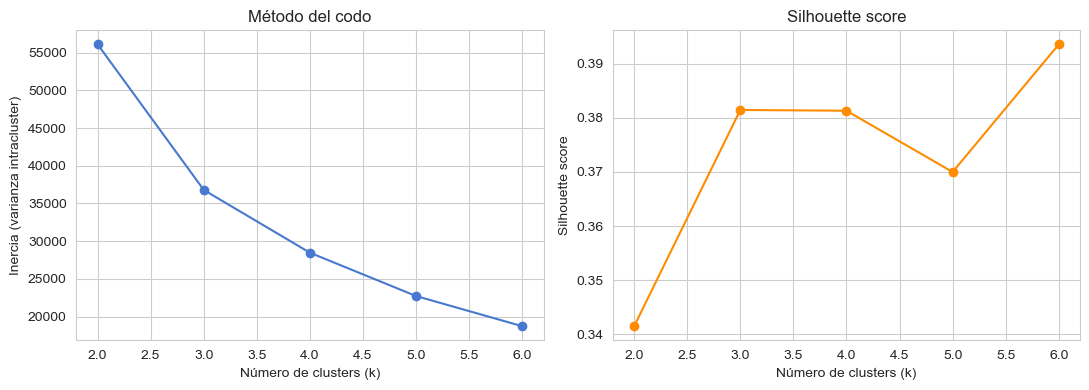

k=2  inercia=56099  silhouette=0.341
k=3  inercia=36789  silhouette=0.381
k=4  inercia=28468  silhouette=0.381
k=5  inercia=22724  silhouette=0.370
k=6  inercia=18720  silhouette=0.394


In [130]:
inertias, sils = [], []
ks = range(2, 7)
for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sils.append(silhouette_score(X_scaled, labels, sample_size=10000, random_state=42))

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(list(ks), inertias, 'o-')
ax[0].set_xlabel('Número de clusters (k)')
ax[0].set_ylabel('Inercia (varianza intracluster)')
ax[0].set_title('Método del codo')

ax[1].plot(list(ks), sils, 'o-', color='darkorange')
ax[1].set_xlabel('Número de clusters (k)')
ax[1].set_ylabel('Silhouette score')
ax[1].set_title('Silhouette score')
plt.tight_layout()
plt.show()

for k, i, s in zip(ks, inertias, sils):
    print(f'k={k}  inercia={i:.0f}  silhouette={s:.3f}')

Notamos que el codo se ubica en k=3. La caída de inercia entre k=2 y k=3 (-34%) es mucho mayor que las siguientes (-23%, -20%, -18%), y el silhouette score en k=3 (0.38) es casi igual al de k=4. Se elige **k=3** por ser la solución más simple e interpretable dentro de este empate.

Así, hacemos el ajuste final de K-Means con k=3:

In [131]:
kmeans_final = KMeans(n_clusters=3, random_state=42, n_init=10)
df['cluster_imce_act'] = kmeans_final.fit_predict(X_scaled)

resumen_clusters = df.groupby('cluster_imce_act')[['imce', 'act_fisica']].agg(['mean', 'std'])
tamaños = df['cluster_imce_act'].value_counts().sort_index()
resumen_clusters['n'] = tamaños

tabla_estilizada = resumen_clusters.style \
    .set_properties(**{'text-align': 'center'}) \
    .set_table_styles([{'selector': 'th', 'props': [('text-align', 'center')]}]) \
    .format(precision=3)

tabla_estilizada

Visualizamos los clusters espacialmente:

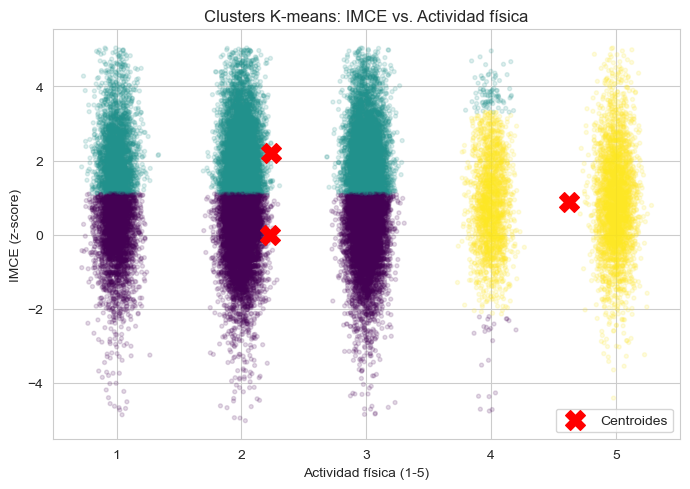

In [132]:
plt.figure(figsize=(7, 5))
jitter = np.random.normal(0, 0.08, size=len(df))
scatter = plt.scatter(df['act_fisica'] + jitter, df['imce'], c=df['cluster_imce_act'],
                       cmap='viridis', alpha=0.15, s=8)
centers_original = scaler.inverse_transform(kmeans_final.cluster_centers_)
plt.scatter(centers_original[:, 1], centers_original[:, 0], c='red', marker='X', s=200,
            label='Centroides')
plt.xlabel('Actividad física (1-5)')
plt.ylabel('IMCE (z-score)')
plt.title('Clusters K-means: IMCE vs. Actividad física')
plt.legend()
plt.tight_layout()
plt.show()

A partir de los tres clusters podemos crear la siguiente tabla resumen:

| Cluster | n | IMCE promedio | Act. física promedio | Lectura |
|---|---|---|---|---|
| 0 | 19.595 (47%) | ≈ 0.00 | ≈ 2.23 | Peso normal, actividad física típica (baja-media) |
| 1 | 17.026 (41%) | ≈ 2.22 | ≈ 2.24 | Sobrepeso/obesidad, actividad física típica (baja-media) |
| 2 | 5.233 (12%) | ≈ 0.89 | ≈ 4.62 | Actividad física muy alta (4-5 veces/semana), IMCE intermedio |

**Conclusiones:**

- La primera partición que encuentra K-means no es por IMCE, sino por nivel de actividad física. El grupo de actividad muy alta (cluster 2) se separa con claridad porque es un segmento pequeño y homogéneo en el extremo de la escala (4-5). Despues de aislar a este grupo, el algoritmo distingue entre peso normal y sobrepeso/obesidad dentro de la mayoría con actividad típica (clusters 0 y 1).

- Es notable que el grupo más activo (cluster 2) no es el de menor IMCE. Su IMCE promedio (0.89) es mayor que el del cluster de peso normal (0.00) aunque menor que el de sobrepeso (2.22). Esto tal vez se debe a que en niños muy activos parte del IMC corresponde a mayor masa muscular y no sólo a grasa corporal, o que la actividad física muy frecuente no necesariamente compensa otros determinantes del peso (dieta, genética, etc.).

**Nota:** guardamos la base con los clusters para usar en la siguiente pregunta:

In [133]:
df.to_csv('junaeb2n_full.csv', index=False)

# Pregunta 7

### Elija el grupo con mayor IMCE promedio en base a la Pregunta 6. Estime nuevamente su mejor modelo de la Pregunta 5. ¿Qué puede concluir de sus resultados?

## Solución:

De los 3 clusters de la Pregunta 6, el cluster 1 es el que tiene el mayor IMCE promedio. Lo identificaremos de forma programática para que el notebook siga siendo reproducible si cambia el orden de las etiquetas de cluster.

**Mejor modelo de la Pregunta 5:** de los cuatro modelos comparados, **Random Forest** obtuvo el mejor accuracy (0.553) junto con un costo computacional mínimo, por lo que es el que reestimamos aquí (XGBoost es similarmente eficiente pero con accuracy levemente menor; SVM y Stacking son mucho mas costosos sin mejorar el desempeño).

In [134]:
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score

df = pd.read_csv('junaeb2n_full.csv')

imce_promedio_por_cluster = df.groupby('cluster_imce_act')['imce'].mean()
print(imce_promedio_por_cluster.round(3))

cluster_alto_imce = imce_promedio_por_cluster.idxmax()
print(f'\nCluster seleccionado (mayor IMCE promedio): {cluster_alto_imce}')

sub7 = df[(df['cluster_imce_act'] == cluster_alto_imce) & (df['madre_work'] != 0)].copy()
feature_cols = ['factor_curiosidad', 'factor_afecto', 'factor_juego_social']
X7 = sub7[feature_cols]
y7 = (sub7['madre_work'] == 1).astype(int)

print(f'N en el subgrupo (excl. desempleadas): {len(sub7)}')
print('Balance de clases:', y7.value_counts(normalize=True).round(3).to_dict())

cluster_imce_act
0    0.003
1    2.217
2    0.886
Name: imce, dtype: float64

Cluster seleccionado (mayor IMCE promedio): 1
N en el subgrupo (excl. desempleadas): 15225
Balance de clases: {1: 0.558, 0: 0.442}


Hacemos nuevamente la partición train/test y la optimización de hiperparámetros (Random Forest):

In [135]:
X7_train, X7_test, y7_train, y7_test = train_test_split(
    X7, y7, test_size=0.2, random_state=42, stratify=y7
)

param_grid = {'n_estimators': [100, 200], 'max_depth': [3, 5, 8], 'min_samples_leaf': [1, 10]}
rf7 = RandomForestClassifier(random_state=42, n_jobs=1)
grid_rf7 = GridSearchCV(rf7, param_grid, cv=5, scoring='accuracy', n_jobs=1)

t0 = time.time()
grid_rf7.fit(X7_train, y7_train)
t_rf7 = time.time() - t0

print(f'Tiempo búsqueda HP: {t_rf7:.1f} s')
print('Mejores hiperparámetros:', grid_rf7.best_params_)
print('Mejor accuracy (5-fold CV):', round(grid_rf7.best_score_, 4))

Tiempo búsqueda HP: 67.2 s
Mejores hiperparámetros: {'max_depth': 3, 'min_samples_leaf': 1, 'n_estimators': 100}
Mejor accuracy (5-fold CV): 0.5617


Evaluamos en el set de prueba solamente dentro del cluster con mayor IMCE:

                 precision    recall  f1-score   support

labor_domestica      0.531     0.057     0.103      1345
       empleada      0.563     0.960     0.710      1700

       accuracy                          0.561      3045
      macro avg      0.547     0.509     0.406      3045
   weighted avg      0.549     0.561     0.442      3045



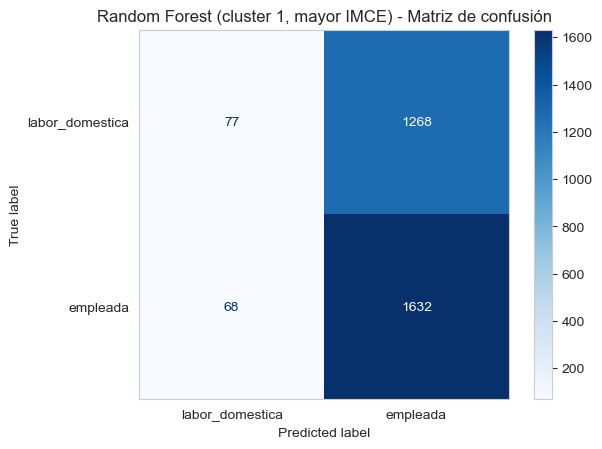

AUC: 0.5149
Accuracy modelo: 0.5612  |  Accuracy línea base: 0.5583


In [136]:
best_rf7 = grid_rf7.best_estimator_
y_pred7 = best_rf7.predict(X7_test)
y_proba7 = best_rf7.predict_proba(X7_test)[:, 1]

print(classification_report(y7_test, y_pred7, digits=3, target_names=['labor_domestica', 'empleada']))

cm7 = confusion_matrix(y7_test, y_pred7)
ConfusionMatrixDisplay(cm7, display_labels=['labor_domestica', 'empleada']).plot(cmap='Blues')
plt.grid(False)
plt.title(f'Random Forest (cluster {cluster_alto_imce}, mayor IMCE) - Matriz de confusión')
plt.show()

auc7 = roc_auc_score(y7_test, y_proba7)
baseline7 = max(y7_test.mean(), 1 - y7_test.mean())
print(f'AUC: {auc7:.4f}')
print(f'Accuracy modelo: {(y_pred7 == y7_test).mean():.4f}  |  Accuracy línea base: {baseline7:.4f}')

Analizamos la importancia de variables en este subgrupo:

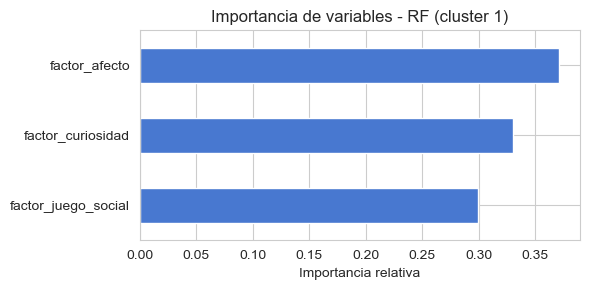

factor_juego_social    0.299
factor_curiosidad      0.330
factor_afecto          0.371
dtype: float64

In [137]:
importancias7 = pd.Series(best_rf7.feature_importances_, index=feature_cols).sort_values()
importancias7.plot(kind='barh', figsize=(6, 3),
                    title=f'Importancia de variables - RF (cluster {cluster_alto_imce})')
plt.xlabel('Importancia relativa')
plt.tight_layout()
plt.show()
importancias7.round(3)

**Conclusiones:**

- Al restringir la muestra al grupo con mayor IMCE, el modelo no mejora. El accuracy (0.561) vuelve a estar pegado a la línea base de predicción trivial (0.558), y el AUC (0.515) es incluso más bajo que el obtenido con la muestra completa en la Pregunta 4 (0.525). La matriz de confusión muestra el mismo patrón de siempre (alto recall en 'empleada', recall casi nulo en 'labor doméstica').

- Esto descarta la idea de que la débil capacidad predictiva encontrada en la Pregunta 4 se debiera a estar mezclando subgrupos heterogéneos (en términos de IMCE) que se cancelaban entre sí. Al aislar un grupo más homogéneo, el problema de fondo persiste: los factores socioemocionales del niño siguen sin contener información relevante sobre la situación laboral de la madre, independientemente de si el niño tiene sobrepeso o no.

# Pregunta 8

### Revise el notebook Sentiment_Analysis.ipynb. Considere la variable *narrative* en el dataset. Utilice las funciones para tokenizar los textos y luego entrene un modelo adecuado para contrastar con la Pregunta 5 (SVC), excluyendo las variables *sk*. Compare y discuta sus resultados.

## Solución:

Basándonos en el notebook `Sentiment_Analysis.ipynb`, seguimos el siguiente flujo de NLP: 

1) limpieza de texto con stopwords en español (función `tweet_to_words`)
2) vectorización con `CountVectorizer`
3) clasificación con **SVC**. 

Adaptamos cada paso:

- Se tiene que `narrative` es un texto generado automáticamente a partir de `sk1`-`sk13`, por lo que teóricamente contiene la misma información que ya resumimos en los factores latentes de la Pregunta 3 (solamente que expresada en lenguaje natural en vez de variables estructuradas).
- Por el enunciado, excluimos a las variables `sk` (y también a los factores derivados de ellas). El único input del modelo es el texto de `narrative`.
- El target es el mismo de las Preguntas 4, 5 y 7 (`madre_work`, excluyendo desempleadas).

Cargamos los datos y limpiamos el texto:

In [142]:
import pandas as pd
import numpy as np
import re
import time
import nltk
from nltk.corpus import stopwords
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score

nltk.download('stopwords', quiet=True)
stops_es = set(stopwords.words('spanish'))

df = pd.read_csv('junaeb2n_clean.csv')
sub = df[df['madre_work'] != 0].copy()

def narrative_to_words(text):
    """Version adaptada de tweet_to_words (Sentiment_Analysis.ipynb). En vez de remover
    hashtags, removemos puntuación/numeros, pasamos a minúsculas y
    filtramos stopwords en español."""
    letters_only = re.sub(r'[^a-zA-ZáéíóúÁÉÍÓÚñÑ\s]', ' ', text)
    words = letters_only.lower().split()
    meaningful_words = [w for w in words if w not in stops_es]
    return ' '.join(meaningful_words)

sub['clean_narrative'] = sub['narrative'].apply(narrative_to_words)

Hacemos la partición train/test y la vectorización:

In [143]:
x = sub['clean_narrative']
y = (sub['madre_work'] == 1).astype(int)

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

vect_tunned = CountVectorizer(ngram_range=(1, 2), min_df=5)
vect_tunned.fit(x_train)

x_train_dtm = vect_tunned.transform(x_train)
x_test_dtm = vect_tunned.transform(x_test)
print(f'Dimensión matriz documento-término (train): {x_train_dtm.shape}')

Dimensión matriz documento-término (train): (30036, 1234)


Conectando con lo que hablamos en la Pregunta 5 acerca de la eficiencia, acá entrenaremos un SVC lineal sobre una submuestra estratificada, y después evaluar sobre el set de prueba completo:

In [147]:
idx_sub, _ = train_test_split(np.arange(x_train_dtm.shape[0]), train_size=6000,
                               random_state=42, stratify=y_train)
x_train_sub = x_train_dtm[idx_sub]
y_train_sub = y_train.iloc[idx_sub]

t0 = time.time()
model_svc_text = SVC(kernel='linear', random_state=10)
model_svc_text.fit(x_train_sub, y_train_sub)
t_fit_svc_text = time.time() - t0
print(f'Tiempo de ajuste (submuestra 6.000): {t_fit_svc_text:.2f} s')

Tiempo de ajuste (submuestra 6.000): 23.17 s


                 precision    recall  f1-score   support

labor_domestica      0.475     0.387     0.427      3405
       empleada      0.559     0.645     0.599      4104

       accuracy                          0.528      7509
      macro avg      0.517     0.516     0.513      7509
   weighted avg      0.521     0.528     0.521      7509



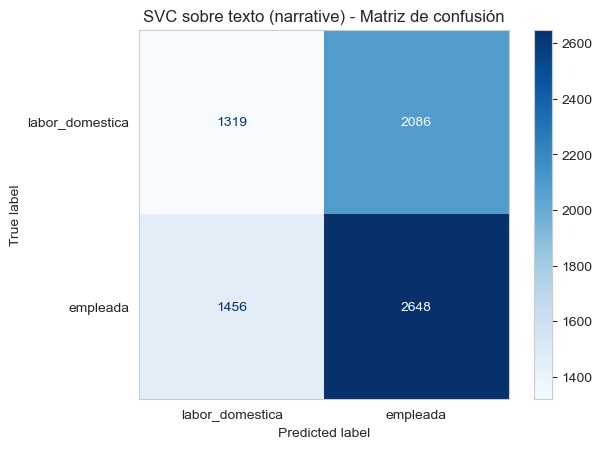

AUC: 0.5159
Accuracy modelo: 0.5283  |  Accuracy línea base: 0.5465


In [148]:
pred = model_svc_text.predict(x_test_dtm)
score = model_svc_text.decision_function(x_test_dtm)

print(classification_report(y_test, pred, digits=3, target_names=['labor_domestica', 'empleada']))

cm = confusion_matrix(y_test, pred)
ConfusionMatrixDisplay(cm, display_labels=['labor_domestica', 'empleada']).plot(cmap='Blues')
plt.grid(False)
plt.title('SVC sobre texto (narrative) - Matriz de confusión')
plt.show()

auc = roc_auc_score(y_test, score)
baseline_acc = max(y_test.mean(), 1 - y_test.mean())
print(f'AUC: {auc:.4f}')
print(f'Accuracy modelo: {(pred == y_test).mean():.4f}  |  Accuracy línea base: {baseline_acc:.4f}')

Veamos cuales son las palabras, o más n-gramas, más relevantes para la clasificación:

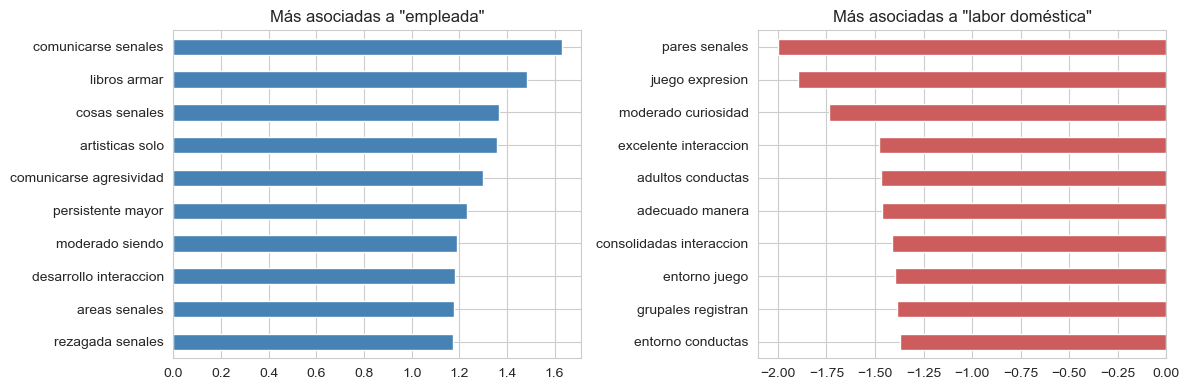

In [150]:
coefs = pd.Series(model_svc_text.coef_.toarray()[0], index=vect_tunned.get_feature_names_out())

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
coefs.sort_values(ascending=False).head(10).plot(kind='barh', ax=ax[0], color='steelblue')
ax[0].set_title('Más asociadas a "empleada"')
ax[0].invert_yaxis()

coefs.sort_values().head(10).plot(kind='barh', ax=ax[1], color='indianred')
ax[1].set_title('Más asociadas a "labor doméstica"')
ax[1].invert_yaxis()
plt.tight_layout()
plt.show()

**Conclusiones:**

- El modelo de texto alcanza Accuracy ≈ 0.528 y AUC ≈ 0.516, resultados que quedan por debajo de la línea base (0.547) y del SVM sobre los factores latentes en la Pregunta 5 (Accuracy 0.552, AUC 0.534). O sea, representar la información socioemocional como texto libre no aporta una mejor predicción que representarla como 3 factores numericos. Quizá, al tener el modelo de texto más parametros sobre los cuales sobreajustar ruido, es lo que explica el desempeño ligeramente peor.

- Teniendo también en cuenta a las Preguntas 4, 5 y 7; sin importar si la información socioemocional del niño se representa mediante las 12 variables `sk` originales, los 3 factores del CFA, un subgrupo de IMCE mas homogéneo, o el texto narrativo generado a partir de las mismas variables, ningún modelo logra superar de forma sólida la predicción trivial de la clase mayoritaria al intentar predecir si la madre trabaja.

- La conclusión general se mantiene: el desarrollo socioemocional de un niño, medido de cualquiera de estas formas, no es un buen predictor de la situación laboral de su madre.